In [18]:
import sys
import numpy as np
import subprocess

print(sys.executable)
print(np.__file__)
subprocess.run([sys.executable, "-m", "pip", "show", "numpy"])

d:\code\Collection_of_virtual\VLM_space\Scripts\python.exe
d:\code\Collection_of_virtual\VLM_space\Lib\site-packages\numpy\__init__.py


CompletedProcess(args=['d:\\code\\Collection_of_virtual\\VLM_space\\Scripts\\python.exe', '-m', 'pip', 'show', 'numpy'], returncode=0)

In [1]:

import numpy as np
print(np.__version__)

1.26.4


In [2]:
!uv pip list

Package                 Version
----------------------- -----------
annotated-doc           0.0.4
anyio                   4.12.1
asttokens               3.0.1
certifi                 2026.2.25
click                   8.3.1
colorama                0.4.6
comm                    0.2.3
contourpy               1.3.3
cycler                  0.12.1
debugpy                 1.8.20
decorator               5.2.1
executing               2.2.1
filelock                3.25.1
fonttools               4.62.0
fsspec                  2026.2.0
h11                     0.16.0
hf-xet                  1.3.2
httpcore                1.0.9
httpx                   0.28.1
huggingface-hub         1.6.0
idna                    3.11
ipykernel               7.2.0
ipython                 9.11.0
ipython-pygments-lexers 1.1.1
jedi                    0.19.2
jinja2                  3.1.6
jupyter-client          8.8.0
jupyter-core            5.9.1
kiwisolver              1.5.0
markdown-it-py          4.0.0
markupsafe       

Using Python 3.12.0 environment at: D:\code\Collection_of_virtual\VLM_space


In [12]:
!uv pip install numpy

Using Python 3.12.0 environment at: D:\code\Collection_of_virtual\VLM_space
Audited 1 package in 60ms


d:\code\Collection_of_virtual\VLM_space\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
d:\code\Collection_of_virtual\VLM_space\Lib\site-packages\huggingface_hub\file_download.py:129: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in C:\Users\lijih\.cache\huggingface\hub\models--openai--clip-vit-base-patch32. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order t

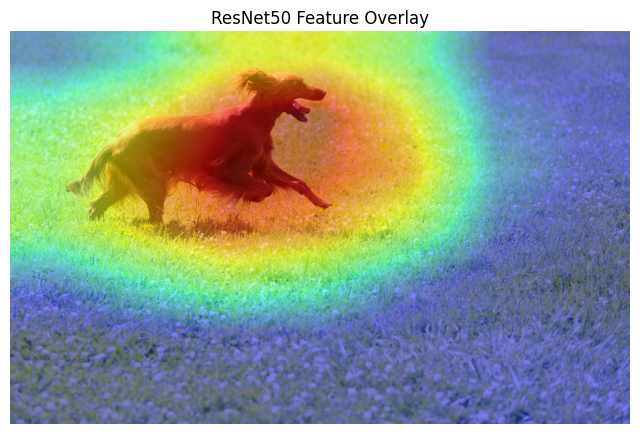

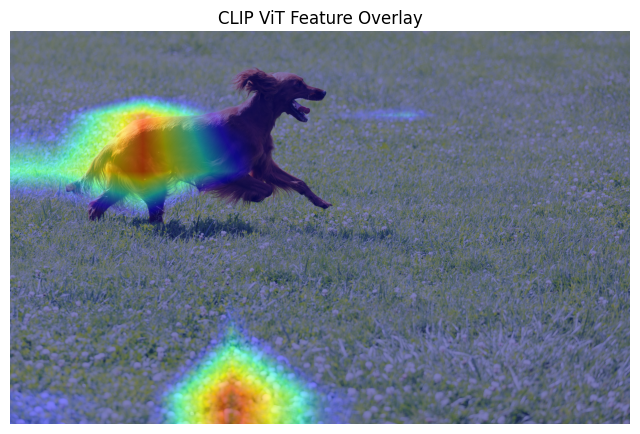

In [ ]:
#CNN과 CLIP 기반 모델의 차이
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np
import torch.nn.functional as F
from torchvision import models, transforms
from transformers import CLIPVisionModel, CLIPImageProcessor
from PIL import Image

def get_resnet_features(image_path):
    model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
    model.eval()
    
    transform = transforms.Compose([
        transforms.Resize((224, 224)),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ])
    
    image = Image.open(image_path).convert('RGB')
    input_tensor = transform(image).unsqueeze(0)
    
    features = []
    
    def hook_fn(module, input, output):
        features.append(output)
        
    handle = model.layer4.register_forward_hook(hook_fn)
    
    with torch.no_grad():
        model(input_tensor)
        
    handle.remove()
    return features[0], image

def get_clip_features(image_path):
    model = CLIPVisionModel.from_pretrained("openai/clip-vit-base-patch32")
    processor = CLIPImageProcessor.from_pretrained("openai/clip-vit-base-patch32")
    
    image = Image.open(image_path).convert('RGB')
    inputs = processor(images=image, return_tensors="pt")
    
    with torch.no_grad():
        outputs = model(**inputs, output_hidden_states=True)
        
    return outputs.hidden_states[-1], image

def visualize_overlay(feature_tensor, original_image, title, model_type="cnn"):
    if model_type == "cnn":
        activation = feature_tensor.squeeze(0).mean(dim=0).cpu()
    elif model_type == "vit":
        tokens = feature_tensor.squeeze(0)[1:, :]
        grid_size = int(np.sqrt(tokens.shape[0]))
        activation = tokens.mean(dim=-1).reshape(grid_size, grid_size).cpu()

    activation = activation.unsqueeze(0).unsqueeze(0)
    activation = F.interpolate(
        activation, 
        size=(original_image.size[1], original_image.size[0]), 
        mode='bilinear', 
        align_corners=False
    )
    activation = activation.squeeze().numpy()

    activation = np.maximum(activation, 0)
    if activation.max() > 0:
        activation = (activation - activation.min()) / (activation.max() - activation.min())

    plt.figure(figsize=(8, 8))
    plt.imshow(original_image)
    plt.imshow(activation, cmap='jet', alpha=0.5)
    plt.title(title)
    plt.axis('off')
    plt.show()

def compare_feature_maps_overlay(image_path):
    resnet_feat, orig_img_resnet = get_resnet_features(image_path)
    clip_feat, orig_img_clip = get_clip_features(image_path)
    
    visualize_overlay(resnet_feat, orig_img_resnet, "ResNet50 Feature Overlay", "cnn")
    visualize_overlay(clip_feat, orig_img_clip, "CLIP ViT Feature Overlay", "vit")

compare_feature_maps_overlay(r"C:\Users\lijih\Downloads\red-irish-setter-running-grass.jpg")